In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


## Loading the Dataset


In [3]:
df = pd.read_csv(r'cleaned.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (2000, 25)
  Product_ID         Brand     Category  Price_INR  Units_Sold  \
0   PROD0001         Lakme   Foundation    2672.70          16   
1   PROD0002  Faces Canada     Lipstick     656.53          42   
2   PROD0003        Revlon  Highlighter    1049.53          14   
3   PROD0004  Faces Canada     Eyeliner     273.88          25   
4   PROD0005           MAC   Foundation    3072.61          25   

   Discount_Percent  Revenue_INR  Rating  Customer_Age Customer_Gender  ...  \
0                 5     40625.04     3.1            22          Female  ...   
1                 0     27574.26     4.3            42          Female  ...   
2                15     12489.41     4.9            37          Female  ...   
3                15      5819.95     2.7            34          Female  ...   
4                10     69133.73     3.2            39          Female  ...   

      Month Quarter Day_of_Week Is_weekend  Price_Range    Age_Group  \
0  February       1      Friday       

# MODEL 1 — Predicting Product Returns (Q2)
# Target: Returned (0 = Not Returned, 1 = Returned)


## Step 1 — Select Features and Target


In [4]:
features_return = [
    'Price_INR', 'Units_Sold', 'Discount_Percent', 'Rating',
    'Customer_Age', 'Customer_Gender', 'Skin_Type',
    'Region', 'Sales_Channel', 'Category', 'Brand',
    'Is_weekend', 'Price_Range', 'Age_Group'
]

target_return = 'Returned'

df_model1 = df[features_return + [target_return]].copy()
print("Class Distribution:")
print(df_model1[target_return].value_counts())
print(df_model1[target_return].value_counts(normalize=True).mul(100).round(2))


Class Distribution:
Returned
0    1807
1     193
Name: count, dtype: int64
Returned
0    90.35
1     9.65
Name: proportion, dtype: float64


## Step 2 — Encode Categorical Columns


In [5]:
le = LabelEncoder()
cat_cols = ['Customer_Gender', 'Skin_Type', 'Region', 'Sales_Channel',
            'Category', 'Brand', 'Price_Range', 'Age_Group']

df_encoded1 = df_model1.copy()
for col in cat_cols:
    df_encoded1[col] = le.fit_transform(df_encoded1[col].astype(str))

print("Encoding complete.")
print(df_encoded1.head())


Encoding complete.
   Price_INR  Units_Sold  Discount_Percent  Rating  Customer_Age  \
0    2672.70          16                 5     3.1            22   
1     656.53          42                 0     4.3            42   
2    1049.53          14                15     4.9            37   
3     273.88          25                15     2.7            34   
4    3072.61          25                10     3.2            39   

   Customer_Gender  Skin_Type  Region  Sales_Channel  Category  Brand  \
0                0          2       3              0         4      3   
1                0          4       2              2         6      1   
2                0          2       3              1         5      8   
3                0          1       7              0         2      1   
4                0          0       1              2         4      4   

   Is_weekend  Price_Range  Age_Group  Returned  
0           0            2          1         0  
1           0            1       

## Step 3 — Train Test Split


In [6]:
X1 = df_encoded1.drop(columns=[target_return])
y1 = df_encoded1[target_return]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print(f"Train size : {X1_train.shape[0]}")
print(f"Test size  : {X1_test.shape[0]}")


Train size : 1600
Test size  : 400


## Step 4 — Train Logistic Regression


In [7]:
lr_model1 = LogisticRegression(max_iter=1000, random_state=42)
lr_model1.fit(X1_train, y1_train)
lr_pred1 = lr_model1.predict(X1_test)

print("Logistic Regression — Return Prediction")
print("-" * 50)
print(f"Accuracy : {accuracy_score(y1_test, lr_pred1) * 100:.2f}%")
print()
print(classification_report(y1_test, lr_pred1, target_names=['Not Returned', 'Returned']))


Logistic Regression — Return Prediction
--------------------------------------------------
Accuracy : 90.25%

              precision    recall  f1-score   support

Not Returned       0.90      1.00      0.95       361
    Returned       0.00      0.00      0.00        39

    accuracy                           0.90       400
   macro avg       0.45      0.50      0.47       400
weighted avg       0.81      0.90      0.86       400



## Step 5 — Train Random Forest


In [8]:
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model1.fit(X1_train, y1_train)
rf_pred1 = rf_model1.predict(X1_test)

print("Random Forest — Return Prediction")
print("-" * 50)
print(f"Accuracy : {accuracy_score(y1_test, rf_pred1) * 100:.2f}%")
print()
print(classification_report(y1_test, rf_pred1, target_names=['Not Returned', 'Returned']))


Random Forest — Return Prediction
--------------------------------------------------
Accuracy : 90.25%

              precision    recall  f1-score   support

Not Returned       0.90      1.00      0.95       361
    Returned       0.00      0.00      0.00        39

    accuracy                           0.90       400
   macro avg       0.45      0.50      0.47       400
weighted avg       0.81      0.90      0.86       400



## Step 6 — Confusion Matrix (Random Forest)


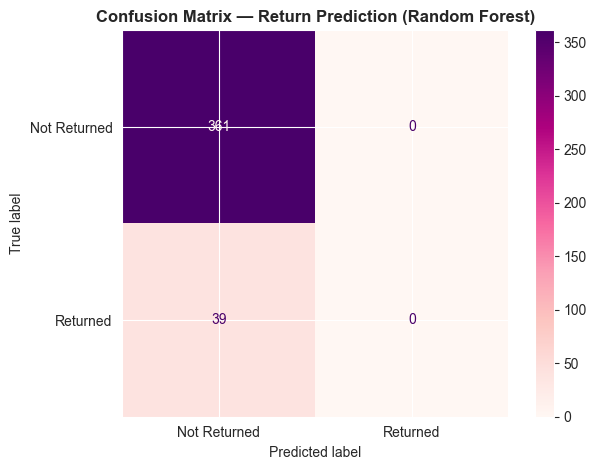

In [9]:
cm1 = confusion_matrix(y1_test, rf_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Not Returned', 'Returned'])
disp1.plot(cmap='RdPu')
plt.title('Confusion Matrix — Return Prediction (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()


## Step 7 — Feature Importance (Random Forest)


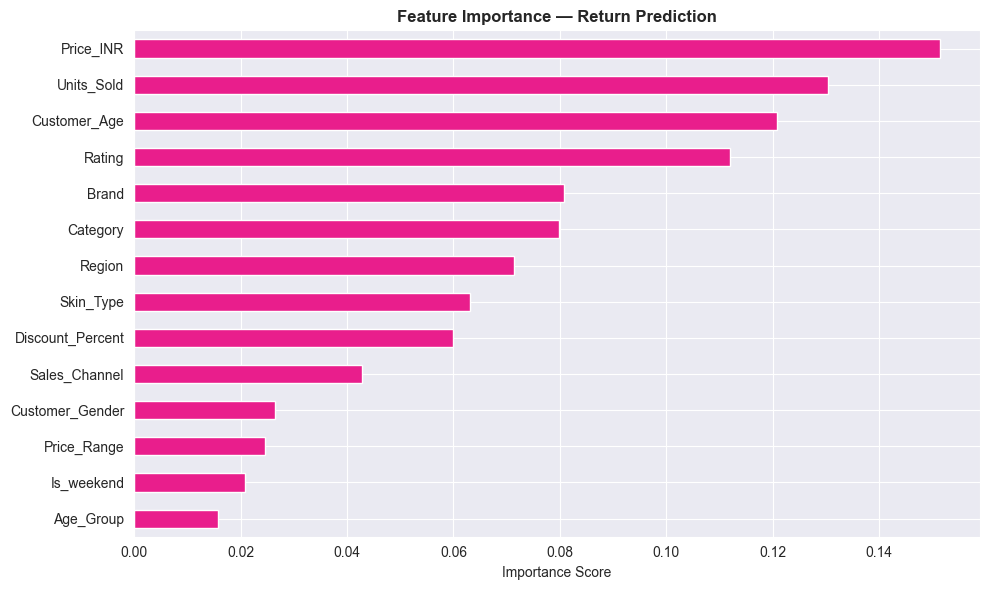


Top 5 Factors Causing Returns:
Price_INR       0.151370
Units_Sold      0.130407
Customer_Age    0.120765
Rating          0.111947
Brand           0.080740
dtype: float64


In [10]:
feat_imp1 = pd.Series(rf_model1.feature_importances_, index=X1.columns)
feat_imp1 = feat_imp1.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp1.plot(kind='barh', color='#E91E8C')
plt.title('Feature Importance — Return Prediction', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Factors Causing Returns:")
print(feat_imp1.head(5))


## Step 8 — ROC Curve (Random Forest)


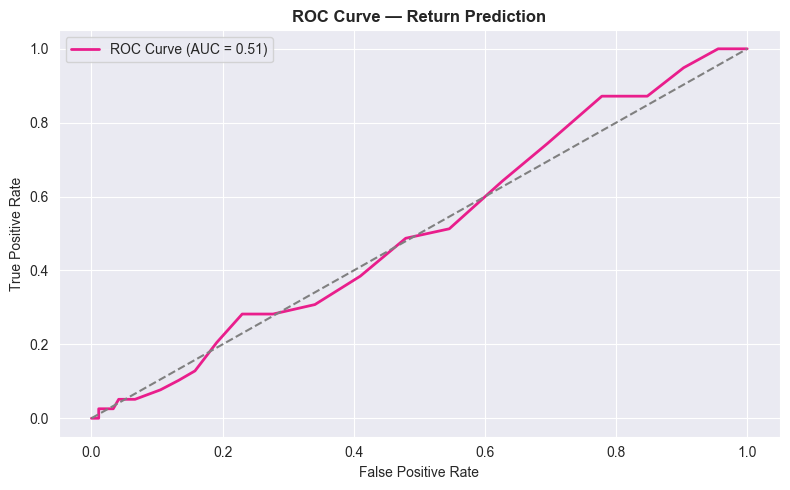

In [11]:
y1_prob = rf_model1.predict_proba(X1_test)[:, 1]
fpr1, tpr1, _ = roc_curve(y1_test, y1_prob)
roc_auc1 = auc(fpr1, tpr1)

plt.figure(figsize=(8, 5))
plt.plot(fpr1, tpr1, color='#E91E8C', lw=2, label=f'ROC Curve (AUC = {roc_auc1:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — Return Prediction', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()


## Model 1 Summary


In [12]:
print("=" * 60)
print("MODEL 1 SUMMARY — Return Prediction")
print("=" * 60)
print(f"Logistic Regression Accuracy : {accuracy_score(y1_test, lr_pred1)*100:.2f}%")
print(f"Random Forest Accuracy       : {accuracy_score(y1_test, rf_pred1)*100:.2f}%")
print(f"ROC-AUC Score                : {roc_auc1:.4f}")
print(f"Best Model                   : {'Random Forest' if accuracy_score(y1_test, rf_pred1) >= accuracy_score(y1_test, lr_pred1) else 'Logistic Regression'}")
print(f"Top Factor Causing Returns   : {feat_imp1.idxmax()}")
print("=" * 60)


MODEL 1 SUMMARY — Return Prediction
Logistic Regression Accuracy : 90.25%
Random Forest Accuracy       : 90.25%
ROC-AUC Score                : 0.5123
Best Model                   : Random Forest
Top Factor Causing Returns   : Price_INR


# MODEL 2 — Predicting High Customer Rating (Q3)
# Target: High_Rating (0 = Rating < 4.0, 1 = Rating >= 4.0)


## Step 1 — Select Features and Target


In [13]:
features_rating = [
    'Price_INR', 'Units_Sold', 'Discount_Percent',
    'Customer_Age', 'Customer_Gender', 'Skin_Type',
    'Region', 'Sales_Channel', 'Category', 'Brand',
    'Is_weekend', 'Price_Range', 'Age_Group', 'Returned'
]

target_rating = 'High_Rating'

df_model2 = df[features_rating + [target_rating]].copy()
print("Class Distribution:")
print(df_model2[target_rating].value_counts())
print(df_model2[target_rating].value_counts(normalize=True).mul(100).round(2))


Class Distribution:
High_Rating
0    1115
1     885
Name: count, dtype: int64
High_Rating
0    55.75
1    44.25
Name: proportion, dtype: float64


## Step 2 — Encode Categorical Columns


In [14]:
df_encoded2 = df_model2.copy()
for col in cat_cols:
    df_encoded2[col] = le.fit_transform(df_encoded2[col].astype(str))

print("Encoding complete.")
print(df_encoded2.head())


Encoding complete.
   Price_INR  Units_Sold  Discount_Percent  Customer_Age  Customer_Gender  \
0    2672.70          16                 5            22                0   
1     656.53          42                 0            42                0   
2    1049.53          14                15            37                0   
3     273.88          25                15            34                0   
4    3072.61          25                10            39                0   

   Skin_Type  Region  Sales_Channel  Category  Brand  Is_weekend  Price_Range  \
0          2       3              0         4      3           0            2   
1          4       2              2         6      1           0            1   
2          2       3              1         5      8           0            1   
3          1       7              0         2      1           0            0   
4          0       1              2         4      4           0            2   

   Age_Group  Returned  High_Ra

## Step 3 — Train Test Split


In [15]:
X2 = df_encoded2.drop(columns=[target_rating])
y2 = df_encoded2[target_rating]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"Train size : {X2_train.shape[0]}")
print(f"Test size  : {X2_test.shape[0]}")


Train size : 1600
Test size  : 400


## Step 4 — Train Logistic Regression


In [16]:
lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X2_train, y2_train)
lr_pred2 = lr_model2.predict(X2_test)

print("Logistic Regression — High Rating Prediction")
print("-" * 50)
print(f"Accuracy : {accuracy_score(y2_test, lr_pred2) * 100:.2f}%")
print()
print(classification_report(y2_test, lr_pred2, target_names=['Low Rating', 'High Rating']))


Logistic Regression — High Rating Prediction
--------------------------------------------------
Accuracy : 54.25%

              precision    recall  f1-score   support

  Low Rating       0.55      0.91      0.69       223
 High Rating       0.42      0.08      0.14       177

    accuracy                           0.54       400
   macro avg       0.49      0.50      0.41       400
weighted avg       0.49      0.54      0.45       400



## Step 5 — Train Random Forest


In [17]:
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X2_train, y2_train)
rf_pred2 = rf_model2.predict(X2_test)

print("Random Forest — High Rating Prediction")
print("-" * 50)
print(f"Accuracy : {accuracy_score(y2_test, rf_pred2) * 100:.2f}%")
print()
print(classification_report(y2_test, rf_pred2, target_names=['Low Rating', 'High Rating']))


Random Forest — High Rating Prediction
--------------------------------------------------
Accuracy : 51.75%

              precision    recall  f1-score   support

  Low Rating       0.55      0.73      0.63       223
 High Rating       0.42      0.25      0.32       177

    accuracy                           0.52       400
   macro avg       0.49      0.49      0.47       400
weighted avg       0.50      0.52      0.49       400



## Step 6 — Confusion Matrix (Random Forest)


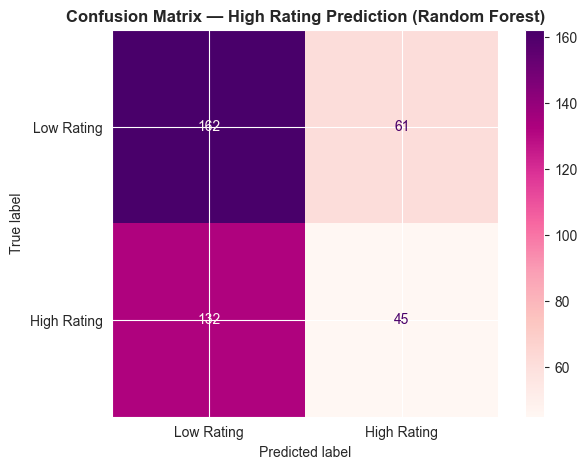

In [18]:
cm2 = confusion_matrix(y2_test, rf_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Low Rating', 'High Rating'])
disp2.plot(cmap='RdPu')
plt.title('Confusion Matrix — High Rating Prediction (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()


## Step 7 — Feature Importance (Random Forest)


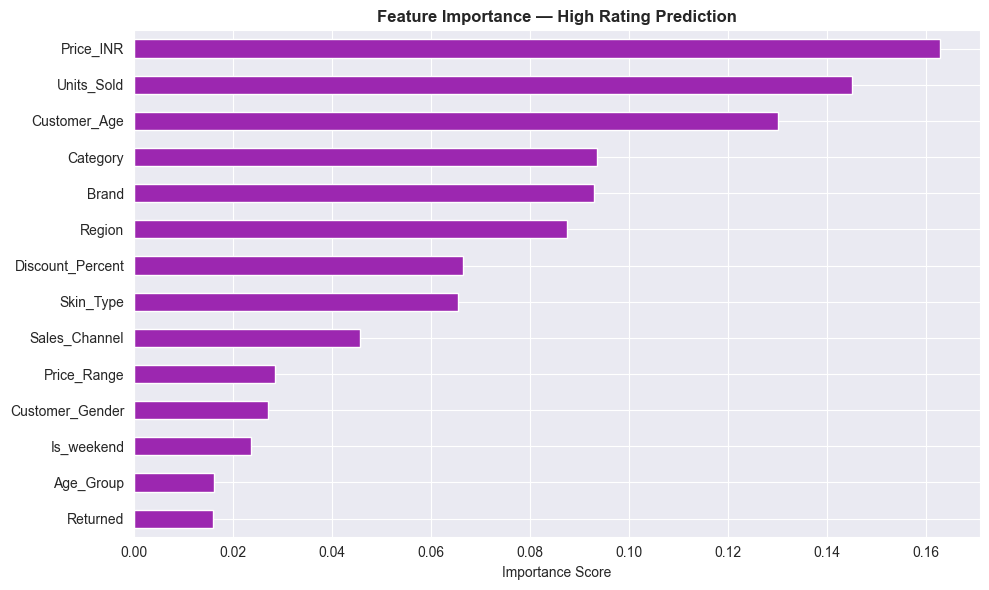


Top 5 Factors Driving High Ratings:
Price_INR       0.162702
Units_Sold      0.145043
Customer_Age    0.130124
Category        0.093540
Brand           0.092826
dtype: float64


In [19]:
feat_imp2 = pd.Series(rf_model2.feature_importances_, index=X2.columns)
feat_imp2 = feat_imp2.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp2.plot(kind='barh', color='#9C27B0')
plt.title('Feature Importance — High Rating Prediction', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Factors Driving High Ratings:")
print(feat_imp2.head(5))


## Step 8 — ROC Curve (Random Forest)


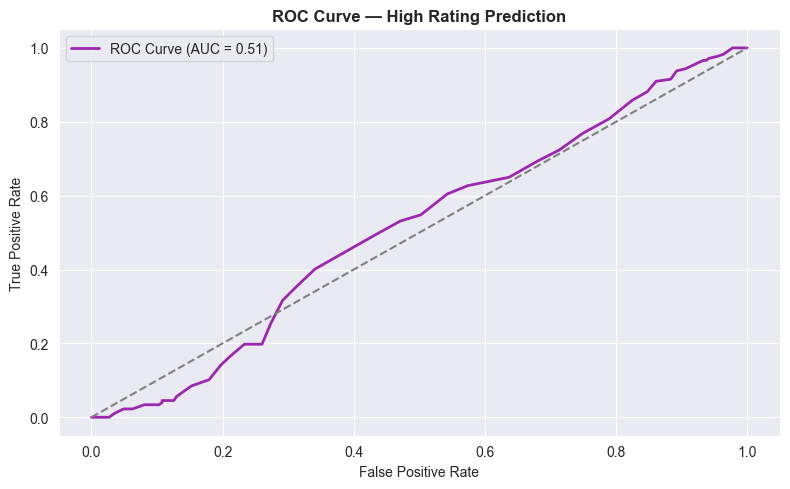

In [20]:
y2_prob = rf_model2.predict_proba(X2_test)[:, 1]
fpr2, tpr2, _ = roc_curve(y2_test, y2_prob)
roc_auc2 = auc(fpr2, tpr2)

plt.figure(figsize=(8, 5))
plt.plot(fpr2, tpr2, color='#9C27B0', lw=2, label=f'ROC Curve (AUC = {roc_auc2:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — High Rating Prediction', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()


## Model 2 Summary


In [21]:
print("=" * 60)
print("MODEL 2 SUMMARY — High Rating Prediction")
print("=" * 60)
print(f"Logistic Regression Accuracy : {accuracy_score(y2_test, lr_pred2)*100:.2f}%")
print(f"Random Forest Accuracy       : {accuracy_score(y2_test, rf_pred2)*100:.2f}%")
print(f"ROC-AUC Score                : {roc_auc2:.4f}")
print(f"Best Model                   : {'Random Forest' if accuracy_score(y2_test, rf_pred2) >= accuracy_score(y2_test, lr_pred2) else 'Logistic Regression'}")
print(f"Top Factor Driving Rating    : {feat_imp2.idxmax()}")
print("=" * 60)


MODEL 2 SUMMARY — High Rating Prediction
Logistic Regression Accuracy : 54.25%
Random Forest Accuracy       : 51.75%
ROC-AUC Score                : 0.5128
Best Model                   : Logistic Regression
Top Factor Driving Rating    : Price_INR


# Final Comparison — Both Models


In [22]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<35} {'LR Acc':>10} {'RF Acc':>10} {'AUC':>8}")
print("-" * 60)
print(f"{'Return Prediction (Q2)':<35} {accuracy_score(y1_test, lr_pred1)*100:>9.2f}% {accuracy_score(y1_test, rf_pred1)*100:>9.2f}% {roc_auc1:>8.4f}")
print(f"{'High Rating Prediction (Q3)':<35} {accuracy_score(y2_test, lr_pred2)*100:>9.2f}% {accuracy_score(y2_test, rf_pred2)*100:>9.2f}% {roc_auc2:>8.4f}")
print("=" * 60)

FINAL MODEL COMPARISON
Model                                   LR Acc     RF Acc      AUC
------------------------------------------------------------
Return Prediction (Q2)                  90.25%     90.25%   0.5123
High Rating Prediction (Q3)             54.25%     51.75%   0.5128
